# BRIDGE deciphers and interprets regulatory pathogenic mutations
Here we walk through the necessary steps to reproduce the main figures of regulatory pathogenic mutations that disrupt dynamic
RNA–protein interactions across genomic contexts using BRIDGE.

## 1. Load BRIDGE model and compute variant scores
Please download the variant dataset from `Figshare`, unzip it, and place it in the expected directory (`BRIDGE/dataset_variant/`). You also need to download the BRIDGE model and place it in the expected directory (`BRIDGE/model/`). Then run the code below to compute the variant scores.

In [ ]:
%%bash
set -euo pipefail

BRIDGE_HOME=../../
cd "$BRIDGE_HOME"
model_save_path=./results/model

python variant_aware.py \
  --ribosnitch \
  --variation_mode before \
  --fasta_sequence_path ./results/reproducibility/ClinVar_TCGA_1000G_resources/ribosnitches/riboSNitches.fasta \
  --Transformer_path ./RBPformer \
  --model_save_path "$model_save_path" \
  --variant_out_file ./results/reproducibility/ClinVar_TCGA_1000G_resources/ribosnitches/ribosnitch_before.txt \
  --device cuda:3


## 2. Downstream analysis

**Note:**
Running the full pipeline across all variants can be time-consuming.  
To make it easier to reproduce the figures directly, we also provide the precomputed files on `Figshare`.

In [2]:
# Downstream analysis: build `odds_ratio.xlsx` for the Fig. 6h beeswarm plot
#
#   1) Filter ribosnitch results to keep only rows with score > 0
#   2) Compute the custom odds-ratio-like scores for:
#        - "All pairwise cells" (original notebook behavior)
#        - Each fixed cell-line pair among a predefined list
#   3) Write a single Excel file (`odds_ratio.xlsx`) that is consumed by the R plotting cell

import math
from collections import defaultdict
from itertools import combinations
from pathlib import Path

import pandas as pd

# -----------------------------
# File paths
# -----------------------------
base_dir = Path("../../results/reproducibility/ClinVar_TCGA_1000G_resources")
ribosnitch_dir = base_dir / "ribosnitches"

before_raw_fp = ribosnitch_dir / "ribosnitch_before.txt"
before_gt0_fp = ribosnitch_dir / "ribosnitch_before_gt0.txt"

# The R cell below reads this file (Sheet1: cell_line_pair + odds_ratio)
xlsx_out_fp = ribosnitch_dir / "odds_ratio.xlsx"

# -----------------------------
# Step 1: Keep only rows with score > 0
# -----------------------------
before_gt0_fp.parent.mkdir(parents=True, exist_ok=True)

with before_raw_fp.open("r", encoding="utf-8") as fin, before_gt0_fp.open("w", encoding="utf-8") as fout:
    for line in fin:
        # The score is stored in the last column
        score = float(line.rstrip("\n").split("\t")[-1])
        if score > 0:
            fout.write(line)

# -----------------------------
# Step 2: Load and preprocess
# -----------------------------
# The file is whitespace-delimited (mixed delimiters), so we parse with a regex separator.
data = pd.read_csv(before_gt0_fp, sep=r"\s+", header=None, engine="python")
data.columns = ["variant", "chr_loc", "variant_loc", "cell1", "cell2", "rbp_cell", "score"]

# Parse RBP and cell line from `rbp_cell` (e.g., "DDX3X_HepG2")
data["rbp"] = data["rbp_cell"].str.split("_").str[0]
data["cell"] = data["rbp_cell"].str.split("_").str[1]


def calculate_score(dynamic: int, common: int, alpha: float = 0.5) -> float:
    """Custom odds-ratio-like score used by the original notebook."""
    return math.log1p(dynamic + alpha * (dynamic * common + 1))


def odds_for_all_pairwise_cells(df: pd.DataFrame) -> pd.DataFrame:
    """
    Reproduce the original 'All pairwise cells' calculation.

    Note:
    - The original code uses `cell1`/`cell2` taken from the *first record* of each (variant, rbp) group.
    - We preserve that behavior here to keep results consistent with the notebook logic.
    """
    counts = defaultdict(lambda: {"dynamic": 0, "common": 0})

    for (_, rbp), group in df.groupby(["variant", "rbp"]):
        _ = counts[rbp]  # ensure every RBP observed in grouping gets an entry (even if counts stay 0)

        cell1 = group.iloc[0]["cell1"]  # first row (original behavior)
        cell2 = group.iloc[0]["cell2"]

        cells_present = set(group["cell"])
        in_cell1 = cell1 in cells_present
        in_cell2 = cell2 in cells_present

        if (in_cell1 and not in_cell2) or (not in_cell1 and in_cell2):
            # Present in exactly one of the two cell lines -> "dynamic"
            counts[rbp]["dynamic"] += 1
        elif in_cell1 and in_cell2:
            # Present in both -> "common"
            counts[rbp]["common"] += 1
        # Else: present in neither -> keep counts unchanged (score becomes log1p(alpha))

    rows = [
        {"cell_line_pair": "All pairwise cells", "odds_ratio": calculate_score(v["dynamic"], v["common"])}
        for _, v in counts.items()
    ]
    return pd.DataFrame(rows)


def odds_for_fixed_pair(df: pd.DataFrame, cell1: str, cell2: str) -> pd.DataFrame:
    """
    Reproduce the original per-pair calculation (cell lines fixed).

    For each (variant, rbp), we check whether `rbp_cell` appears in:
      - only cell1 / only cell2  -> "dynamic"
      - both cell1 and cell2     -> "common"
      - neither                  -> neither counter increases (still included as an entry)
    """
    subset = df[df["cell"].isin([cell1, cell2])]
    counts = defaultdict(lambda: {"dynamic": 0, "common": 0})

    for (_, rbp), group in subset.groupby(["variant", "rbp"]):
        _ = counts[rbp]  # ensure every (variant, rbp) group contributes an entry

        cells_present = set(group["cell"])
        in_cell1 = cell1 in cells_present
        in_cell2 = cell2 in cells_present

        if (in_cell1 and not in_cell2) or (not in_cell1 and in_cell2):
            counts[rbp]["dynamic"] += 1
        elif in_cell1 and in_cell2:
            counts[rbp]["common"] += 1
        # Else: neither present -> keep counts unchanged

    rows = [
        {"cell_line_pair": f"{cell1}_{cell2}", "odds_ratio": calculate_score(v["dynamic"], v["common"])}
        for _, v in counts.items()
    ]
    return pd.DataFrame(rows)


# Cell lines used in the original notebook
cell_lines_of_interest = ["HepG2", "K562", "HEK293", "H9", "HEK293T", "Hela"]

df_all = odds_for_all_pairwise_cells(data)

df_pairs = pd.concat(
    [odds_for_fixed_pair(data, a, b) for a, b in combinations(cell_lines_of_interest, 2)],
    ignore_index=True
)

# Combine into the single table used for plotting
odds_data = pd.concat([df_all, df_pairs], ignore_index=True)

# -----------------------------
# Step 3: Write outputs
# -----------------------------
xlsx_out_fp.parent.mkdir(parents=True, exist_ok=True)
with pd.ExcelWriter(xlsx_out_fp, engine="openpyxl") as writer:
    odds_data.to_excel(writer, sheet_name="Sheet1", index=False)

# (Optional) Save intermediate files for debugging/backward compatibility
df_pairs.to_csv(ribosnitch_dir / "odds_ratio_cells.csv", index=False)

with (ribosnitch_dir / "odds_ratio.txt").open("w", encoding="utf-8") as f:
    for x in df_all["odds_ratio"]:
        f.write(f"All pairwise cells\t{x}\n")

print("Saved Excel:", xlsx_out_fp)
print("Rows:", len(odds_data), "| Groups:", odds_data["cell_line_pair"].nunique())


Saved Excel: ../../results/reproducibility/ClinVar_TCGA_1000G_resources/ribosnitches/odds_ratio.xlsx
Rows: 1274 | Groups: 16


```{important}
**How to use R code in this notebook?**

We have developed several R scripts to perform downstream analyses, and the essential code for key analyses is provided below. To interactively execute the analysis within this notebook, we utilize the `rpy2` package, which allows running R code directly. Thus, please ensure that `rpy2` is installed (`conda install conda-forge::rpy2`). Alternatively, you may extract these R scripts and execute them externally as standalone R scripts.

The code below initializes `rpy2`. After this setup, you can write and execute R code directly within notebook cells by starting with `%%R`.
```

In [3]:
import logging
import rpy2.rinterface_lib.callbacks
from rpy2.robjects import pandas2ri
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)
pandas2ri.activate()
%load_ext rpy2.ipython

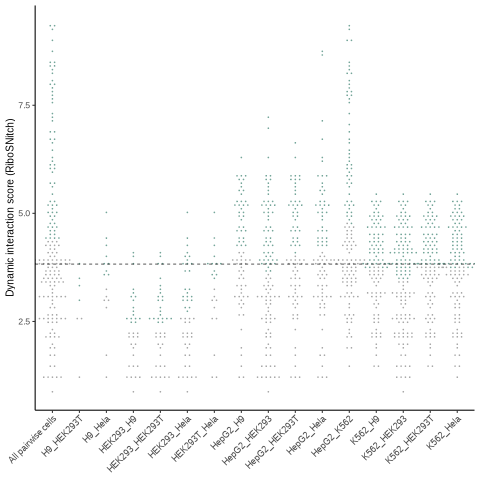

In [4]:
%%R
# Load required packages
library(ggplot2)
library(ggbeeswarm)
library(readxl)
library(dplyr)

# Read data from the Excel file
data_path <- "../../results/reproducibility/ClinVar_TCGA_1000G_resources/ribosnitches/odds_ratio.xlsx"
odds_data <- read_excel(
  data_path,
  sheet = "Sheet1",
  col_types = c("text", "numeric")   # cell_line_pair as text, odds_ratio as numeric
)

# Compute the overall mean odds ratio across all entries (used as a global reference line)
mean_odds_ratio_all <- mean(odds_data$odds_ratio, na.rm = TRUE)

# Group by cell_line_pair and compute the within-group mean odds_ratio
# Then attach it as a new column (mean_odds_ratio) to every row in that group
odds_data <- odds_data %>%
  group_by(cell_line_pair) %>%
  mutate(mean_odds_ratio = mean(odds_ratio, na.rm = TRUE)) %>%
  ungroup()

# Build the plot
p <- ggplot(odds_data, aes(x = cell_line_pair, y = odds_ratio)) +
  geom_beeswarm(
    data = subset(odds_data, odds_ratio >= 0.4),  # filter out low values for plotting
    method = "center",
    aes(color = odds_ratio > mean_odds_ratio),    # color points by whether they exceed the group mean
    alpha = 1, size = 0.15
  ) +
  scale_color_manual(
    values = c("TRUE" = "#75a69a", "FALSE" = "darkgrey")  # colors for above/below group mean
  ) +
  geom_hline(
    yintercept = mean_odds_ratio_all,
    linetype = "dashed", color = "black", linewidth = 0.3 # dashed global mean reference line
  ) +
  # stat_summary(fun = mean, geom = "crossbar", width = 0.4, color = "black", linewidth = 0.15) +
  # (Optional) add a mean crossbar for each group
  labs(x = NULL, y = "Dynamic interaction score (RiboSNitch)") +
  theme_classic() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),    # rotate x-axis labels
    axis.title  = element_text(size = 10),                # axis title font size
    legend.position = "none"                              # hide legend
  )

# Show the plot
p
